In [1]:
%%capture
!pip install torch==2.7.1 torchvision==0.22.1 cuda-bindings==12.9.* # P100 uses old cuda (sm-60)
!pip install git+https://github.com/openai/CLIP.git

In [2]:
from pathlib import Path
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
from typing import Tuple, List, Iterator
from collections import OrderedDict

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import clip
from sklearn.metrics import roc_curve
from torchmetrics import AUROC

## Torch Dataset

In [3]:
torch.manual_seed(42)

# Input paths.
IN_DIR = Path("/kaggle/input/datasets/loubl00m/minimal-data")
MODEL_CKPT = None

# Train params.
TOTAL_FRAMES = 32
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

In [4]:
with open(IN_DIR / "train" / "paths.json", "r") as f:
    train_dict = json.load(f)

with open(IN_DIR / "test" / "paths.json", "r") as ft:
    test_dict = json.load(ft)

In [5]:
# Loading the frame paths and labels from the preprocessed data.
frames = list(map(lambda x: Path(IN_DIR / "train" / x.split("/")[-1]), train_dict.keys()))
y_train = torch.tensor(np.stack(list(train_dict.values()), axis = 0), dtype = DTYPE)

test_frames = list(map(lambda x: Path(IN_DIR / "test" / x.split("/")[-1]), test_dict.keys()))
y_test = torch.tensor(np.stack(list(test_dict.values()), axis = 0), dtype = DTYPE)

In [6]:
class ImageDataset(Dataset):
    """
    PyTorch dataset for loading labeled frame files.

    Args:
        imgs: Sequence of image file paths.
        labels: Sequence of labels corresponding to ``imgs``.
        channels_first: If ``True``, returns images in ``(C, H, W)`` format;
            otherwise, ``(H, W, C)``. 
        transform: Optional transform applied to each image.
    """
    def __init__(self, imgs: List[Path], labels: torch.Tensor,
                 channels_first: bool = True, transform = None):
        super().__init__()
        self.imgs = imgs
        self.labels = labels
        self.transform = transform
        self.channels_first = channels_first

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        img = cv2.cvtColor(cv2.imread(self.imgs[idx]), cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0

        if self.channels_first:
            img = np.transpose(img, (2, 0, 1))
        img = torch.tensor(img, dtype = torch.float16) #DTYPE

        if self.transform:
            img = self.transform(img)
    
        return  img, self.labels[idx]

clip_normalize = transforms.Normalize(
    (0.48145466, 0.4578275, 0.40821073),
    (0.26862954, 0.26130258, 0.27577711),)

data = ImageDataset(frames, y_train, transform = clip_normalize)
test_data = ImageDataset(test_frames, y_test, transform = clip_normalize)

In [7]:
# We have more than enough training data but not enough compute.
# Data augmentation remains in the back pocket for now.
val_split = 0.3
num_workers = 4

n_val   = int(len(data) * val_split) // TOTAL_FRAMES * TOTAL_FRAMES
n_train = len(data) - n_val

# Train, val split. They originate from the same data (FF++).
# The videos are pre-shuffled. Splitting train and val by video (not frame) to prevent leakage.
train_ds = Subset(data, list(range(n_train)))
val_ds = Subset(data, list(range(n_train + 1, len(data))))

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers)

# Test data from DFDC-10.
test_loader = DataLoader(
    test_data, batch_size=TOTAL_FRAMES, shuffle=False,
    num_workers=num_workers)

## Model training

In [8]:
class L2Normalize(torch.nn.Module):
    """
    nn.Module wrapper for the L2Normalization from the functional API.
    """
    def __init__(self, dim: int = 1, eps: float = 1e-12):
        super(L2Normalize, self).__init__()
        self.dim = dim
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.nn.functional.normalize(x, p=2, dim=1, eps=self.eps)

class CLIPBinaryClassifier(torch.nn.Module):
    """
    Wraps a CLIP visual encoder with a binary classification head.
    Args:
        visual: Pretrained CLIP visual encoder.
    """
    def __init__(self, clip_model: torch.nn.Module):
        super().__init__()
        self.visual = clip_model

        for name, param in self.visual.named_parameters():
            param.requires_grad = "ln" in name
 
        embed_dim = self.visual.output_dim  # 1024 for ViT-L/14
        self.l2 = L2Normalize()
        self.linear = torch.nn.Linear(embed_dim, 1, dtype = DTYPE)
 
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.visual(images).float()
        l2 = self.l2(features)
        return self.linear(l2), l2

def load_clip(model_name: str, device = DEVICE) -> torch.nn.Module:
    """
    Loads the visual encoder from a pretrained CLIP model.

    Args:
        model_name: Name of the CLIP model to load.

    Returns:
        The CLIP visual encoder with its final projection layer removed.
    """
    # Taking only the visual model, we won't use their preprocess or the language model.
    clip_model = clip.load(model_name, device=device)[0].visual
    # Removing the final projection and updating output dim to exclude it.
    clip_model.proj = None
    clip_model.output_dim = clip_model.transformer.width
    return clip_model

clip_model = load_clip("ViT-L/14", device = DEVICE)
# Preparing CLIP is done on CPU to not have all loaded components on cuda.
# Then, our model is transfered to GPU.
model = CLIPBinaryClassifier(clip_model).to(DEVICE)

100%|████████████████████████████████████████| 890M/890M [00:06<00:00, 140MiB/s]


In [9]:
class CLIPLoss(torch.nn.Module):
    """
    Loss combining binary classification with embedding alignment and uniformity.
    Follows the Deepfake Detection paper.

    Args:
        alpha: Weight of the alignment loss.
        beta: Weight of the uniformity loss.
    """
    def __init__(self, alpha: float = 0.1, beta: float = 0.5):
        super().__init__()
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.alpha = alpha
        self.beta = beta

    def _align(self, embeddings: torch.Tensor, labels: torch.Tensor):
        """
        Aligns samples with the same labels (1 to 1 and 0 to 0).
        """
        # Embeddings is 2D [B, emb_dim] and labels must be 1D [B, ]
        labels = labels.reshape((-1,))
        assert embeddings.size(0) == labels.size(-1)

        # GenD code. It was unclear what this does without the code.
        # [B, 1] == [1, B]
        # Broadcasts repeating the first labels along the columns and the latter across rows.
        labels_equal_mask = (labels[:, None] == labels[None, :]).triu(diagonal = 1).float()
        # Every (x, y) where x!=y and labels[x]==labels[y]==1.
        positive_indices = torch.nonzero(labels_equal_mask, as_tuple=False)

        if positive_indices.numel() == 0:
            return torch.tensor(0.0, device=embeddings.device)

        # Sum of squared difference across emb_dim to get the distance, mean across the batch.
        return ((embeddings[positive_indices[:, 0]] - embeddings[positive_indices[:, 1]])**2).sum(axis = 1).mean()

    def _uniform(self, embeddings: torch.Tensor):
        """
        Calculates the average squared distance between any two embeddings
        adjusted by a temperature t.
        """
        t = 2
        min_value = 1e-6
        return torch.pdist(embeddings, p=2).pow(2).mul(-t).exp().mean().clamp(min=min_value).log()

    def forward(self, outputs: Tuple[torch.Tensor, torch.Tensor], labels: torch.Tensor):
        out, norm = outputs
        return self.bce(out, labels) + self.alpha * self._align(norm, labels) + self.beta * self._uniform(norm)

In [10]:
class CosineCyclicWarmupLR(torch.optim.lr_scheduler._LRScheduler):
    """
    Learning rate scheduler with cyclic linear warm-up followed by cosine decay.

    Args:
        optimizer: Optimizer whose learning rate is scheduled.
        steps_per_epoch: Number of optimizer steps in one epoch.
        warmup_epochs: Number of warm-up epochs per cycle.
        cycle_epochs: Total number of epochs in each cycle.
        min_lr: Minimum learning rate.
        max_lr: Peak learning rate reached after warm-up.
        last_epoch: Index of the last completed step.

    Returns:
        A learning rate that increases linearly during warm-up and decays
        following a cosine schedule for the remainder of each cycle.
    """
    def __init__(
        self,
        optimizer: torch.optim.Optimizer,
        steps_per_epoch: int,
        warmup_epochs: float = 1.0,
        cycle_epochs: float = 10.0,
        min_lr: float = 1e-5,
        max_lr: float = 3e-4,
        last_epoch: int = -1,
    ):
        self.steps_per_epoch = steps_per_epoch
        self.warmup_steps = warmup_epochs * steps_per_epoch
        self.cycle_steps = cycle_epochs * steps_per_epoch
        self.decay_steps = self.cycle_steps - self.warmup_steps
        self.min_lr = min_lr
        self.max_lr = max_lr
        super().__init__(optimizer, last_epoch)
 
    def get_lr(self):
        step = self.last_epoch  # incremented once per .step() call
        cycle_step = step % self.cycle_steps
 
        if cycle_step < self.warmup_steps:
            # linear warm-up: 1e-5 -> 3e-4 over one epoch
            frac = cycle_step / self.warmup_steps
            lr = self.min_lr + (self.max_lr - self.min_lr) * frac
        else:
            # cosine decay: 3e-4 -> 1e-5 over the remaining nine epochs
            decay_step = cycle_step - self.warmup_steps
            frac = decay_step / self.decay_steps
            cos_factor = 0.5 * (1.0 + math.cos(math.pi * frac))
            lr = self.min_lr + (self.max_lr - self.min_lr) * cos_factor
 
        return [lr for _ in self.optimizer.param_groups]

In [11]:
# Training hyperparams
epochs = 20
lr = 3e-4
min_lr = 1e-5

In [12]:
def train(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 10,
    lr: float = 3e-4,
    min_lr: float = 1e-5,
    device: str | None = None,
    alpha: float = 0.1,
    beta: float  = 0.5,
    start_from_ckpt: Path | str | None = None,
    retrain_ckpt: bool = False
) -> torch.nn.Module:
    """
    Train a CLIP ViT-L/14 binary classifier.
 
     Args:
        model: Model to train.
        train_loader: DataLoader for the training set.
        val_loader: DataLoader for the validation set.
        epochs: Number of training epochs.
        lr: Maximum learning rate.
        min_lr: Minimum learning rate for the scheduler.
        device: Device on which to run training.
        alpha: Weight of the alignment loss.
        beta: Weight of the uniformity loss.
        start_from_ckpt: Optional checkpoint to load before training.
        retrain_ckpt: If ``False``, returns the loaded checkpoint without further
            training.
    
    Returns:
        The best-performing model in evaluation mode.
    """
    print(f"Using device: {device}")
 
    criterion = CLIPLoss(alpha = alpha, beta = beta)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    steps_per_epoch = len(train_loader)
    scheduler = CosineCyclicWarmupLR(optimizer, steps_per_epoch, cycle_epochs = 10,
                    max_lr = lr, min_lr = min_lr)

    val_losses, val_accs, train_losses, train_accs = ([] for _ in range(4))
    best_val_loss = float("inf")
    best_state    = None

    if start_from_ckpt:
        ckpt = torch.load(start_from_ckpt)
        model.load_state_dict(ckpt)
        best_state  = model.state_dict()
        if not retrain_ckpt:
            return model.eval()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
 
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)   # (B,) → (B, 1)
 
            optimizer.zero_grad()
            outputs, l2 = model(images)                            # (B, 1) in [0, 1]
            loss    = criterion((outputs, l2), labels)
    
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss    += loss.item() * images.size(0)
            preds          = (outputs >= 0).float()
            train_correct += (preds == labels).sum().item()


 
        train_loss /= n_train
        train_acc   = train_correct / n_train
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
 
        model.eval()
        val_loss = 0.0
        val_correct = 0
 
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
 
                outputs, l2 = model(images)
                loss        = criterion((outputs, l2), labels)
                
                val_loss   += loss.item() * images.size(0)
                preds       = (outputs >= 0.).float()
                val_correct += (preds == labels).sum().item()
 
        val_loss /= n_val
        val_acc   = val_correct / n_val
        val_losses.append(val_loss)
        val_accs.append(val_acc)
 
        print(
            f"Epoch {epoch:>3}/{epochs} | "
            f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
            f"Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )
 
        # Save the best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ New best model saved (val_loss={best_val_loss:.4f})")
    
    if best_state is not None:
        torch.save(best_state, 'best_model.pt')
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), f"epoch_{epoch}.pt")

    history = {"train_losses":train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs}

    return model.eval(), history


model, history = train(model, train_loader, val_loader, epochs = epochs, lr = lr,
        device = DEVICE, start_from_ckpt = MODEL_CKPT, min_lr = min_lr)
print("Training done.")

Using device: cuda
Epoch   1/20 | Train loss: 0.3419, acc: 0.2750 | Val   loss: 0.5060, acc: 0.1875
  ✓ New best model saved (val_loss=0.5060)
Epoch   2/20 | Train loss: 0.3289, acc: 0.7312 | Val   loss: 0.4810, acc: 0.9688
  ✓ New best model saved (val_loss=0.4810)
Epoch   3/20 | Train loss: 0.3021, acc: 0.8000 | Val   loss: 0.4591, acc: 0.9688
  ✓ New best model saved (val_loss=0.4591)
Epoch   4/20 | Train loss: 0.2811, acc: 0.8000 | Val   loss: 0.4412, acc: 0.9688
  ✓ New best model saved (val_loss=0.4412)
Epoch   5/20 | Train loss: 0.2617, acc: 0.8000 | Val   loss: 0.4268, acc: 0.9688
  ✓ New best model saved (val_loss=0.4268)
Epoch   6/20 | Train loss: 0.2507, acc: 0.8000 | Val   loss: 0.4158, acc: 0.9688
  ✓ New best model saved (val_loss=0.4158)
Epoch   7/20 | Train loss: 0.2395, acc: 0.8000 | Val   loss: 0.4085, acc: 0.9688
  ✓ New best model saved (val_loss=0.4085)
Epoch   8/20 | Train loss: 0.2312, acc: 0.8000 | Val   loss: 0.4042, acc: 0.9688
  ✓ New best model saved (val_lo

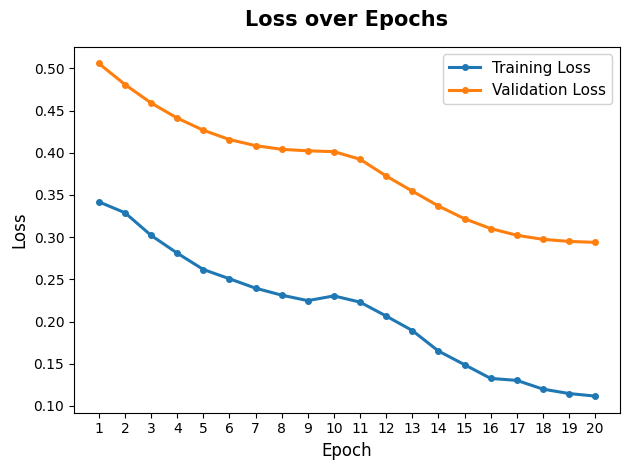

In [13]:
epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, history["train_losses"], 
        label="Training Loss", linewidth=2.2, marker='o', markersize=4)
plt.plot(epochs_range, history["val_losses"], 
        label="Validation Loss", linewidth=2.2, marker='o', markersize=4)

plt.title("Loss over Epochs", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.legend(fontsize=11, frameon=True, framealpha=0.9, loc='upper right')
plt.xticks(list(epochs_range))

plt.tight_layout()
plt.show()

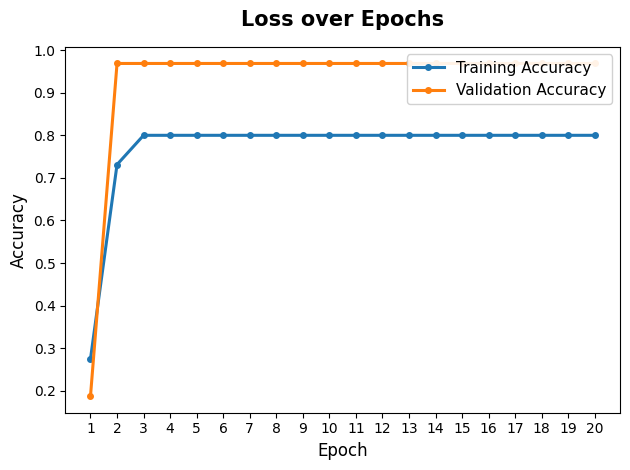

In [14]:
plt.plot(epochs_range, history["train_accs"], 
        label="Training Accuracy", linewidth=2.2, marker='o', markersize=4)
plt.plot(epochs_range, history["val_accs"], 
        label="Validation Accuracy", linewidth=2.2, marker='o', markersize=4)

plt.title("Loss over Epochs", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend(fontsize=11, frameon=True, framealpha=0.9, loc='upper right')
plt.xticks(list(epochs_range))

plt.tight_layout()
plt.show()

In [15]:
def scale_img(img: torch.Tensor| np.ndarray) -> torch.Tensor | np.ndarray:
    """
    Min-max normalizes an image to the range ``[0, 1]``.
    
    Args:
        img: Input image as a NumPy array or PyTorch tensor.
    
    Returns:
        The normalized image with the same type as the input.
    """
    mi, ma = img.min(), img.max()
    img = (img - mi) / (ma - mi)
    return img

def plot_predictions(imgs: torch.Tensor | np.ndarray , preds: torch.Tensor | np.ndarray,
                     labels: torch.Tensor | np.ndarray, fontsize: int = 20):
    """
    Displays a batch of images with their predicted fake probabilities and labels.
    
    Args:
        imgs: Batch of images in ``(N, C, H, W)`` format.
        preds: Predicted fake probabilities for each image.
        labels: Ground-truth binary labels (0 = real, 1 = fake).
        fontsize: Font size used for subplot titles.
    """
    imgs, preds, labels = (tens.detach().cpu().numpy().flatten() if not isinstance(tens, np.ndarray) else tens for tens in (imgs, preds, labels) )
    imgs = scale_img(imgs)
    y = min(4, imgs.shape[0] // 2) # Fails if batch is 1.
    fig, axs = plt.subplots(y, max(imgs.shape[0] // y, 2), figsize=(40, 20))
    axs = axs.flatten()
    
    for i in range(min(len(axs), len(labels))):
        img, pred, ax, label = imgs[i], preds[i], axs[i], labels[i]
        ax.imshow(np.transpose(img, [1, 2, 0]).astype(np.float32))
        ax.set_title(f"Predicted {pred*100:0.2f}% fake and is {"fake" if label else "real"}.", 
                    fontsize = fontsize)
        ax.axis("off")
    plt.show()

In [16]:
@torch.no_grad()
def predict_video(model: torch.nn.Module, video: torch.Tensor, device = DEVICE,
                  return_float = True) -> torch.Tensor | float:
    """
    Predicts the probability that a video is fake from its preprocessed frames.
    
    Args:
        model: Trained binary classification model.
        video: Tensor containing the video's preprocessed frames.
        device: Device on which to run inference.
        return_float: If ``True``, returns a Python ``float``; otherwise, returns
            a scalar tensor.
    
    Returns:
        The mean predicted fake probability across all frames.
    """

    video = video.to(device)
    out, _ = model(video)
    prob = torch.nn.functional.sigmoid(out).mean()
    if return_float:
        return prob.item()
    else:
        return prob

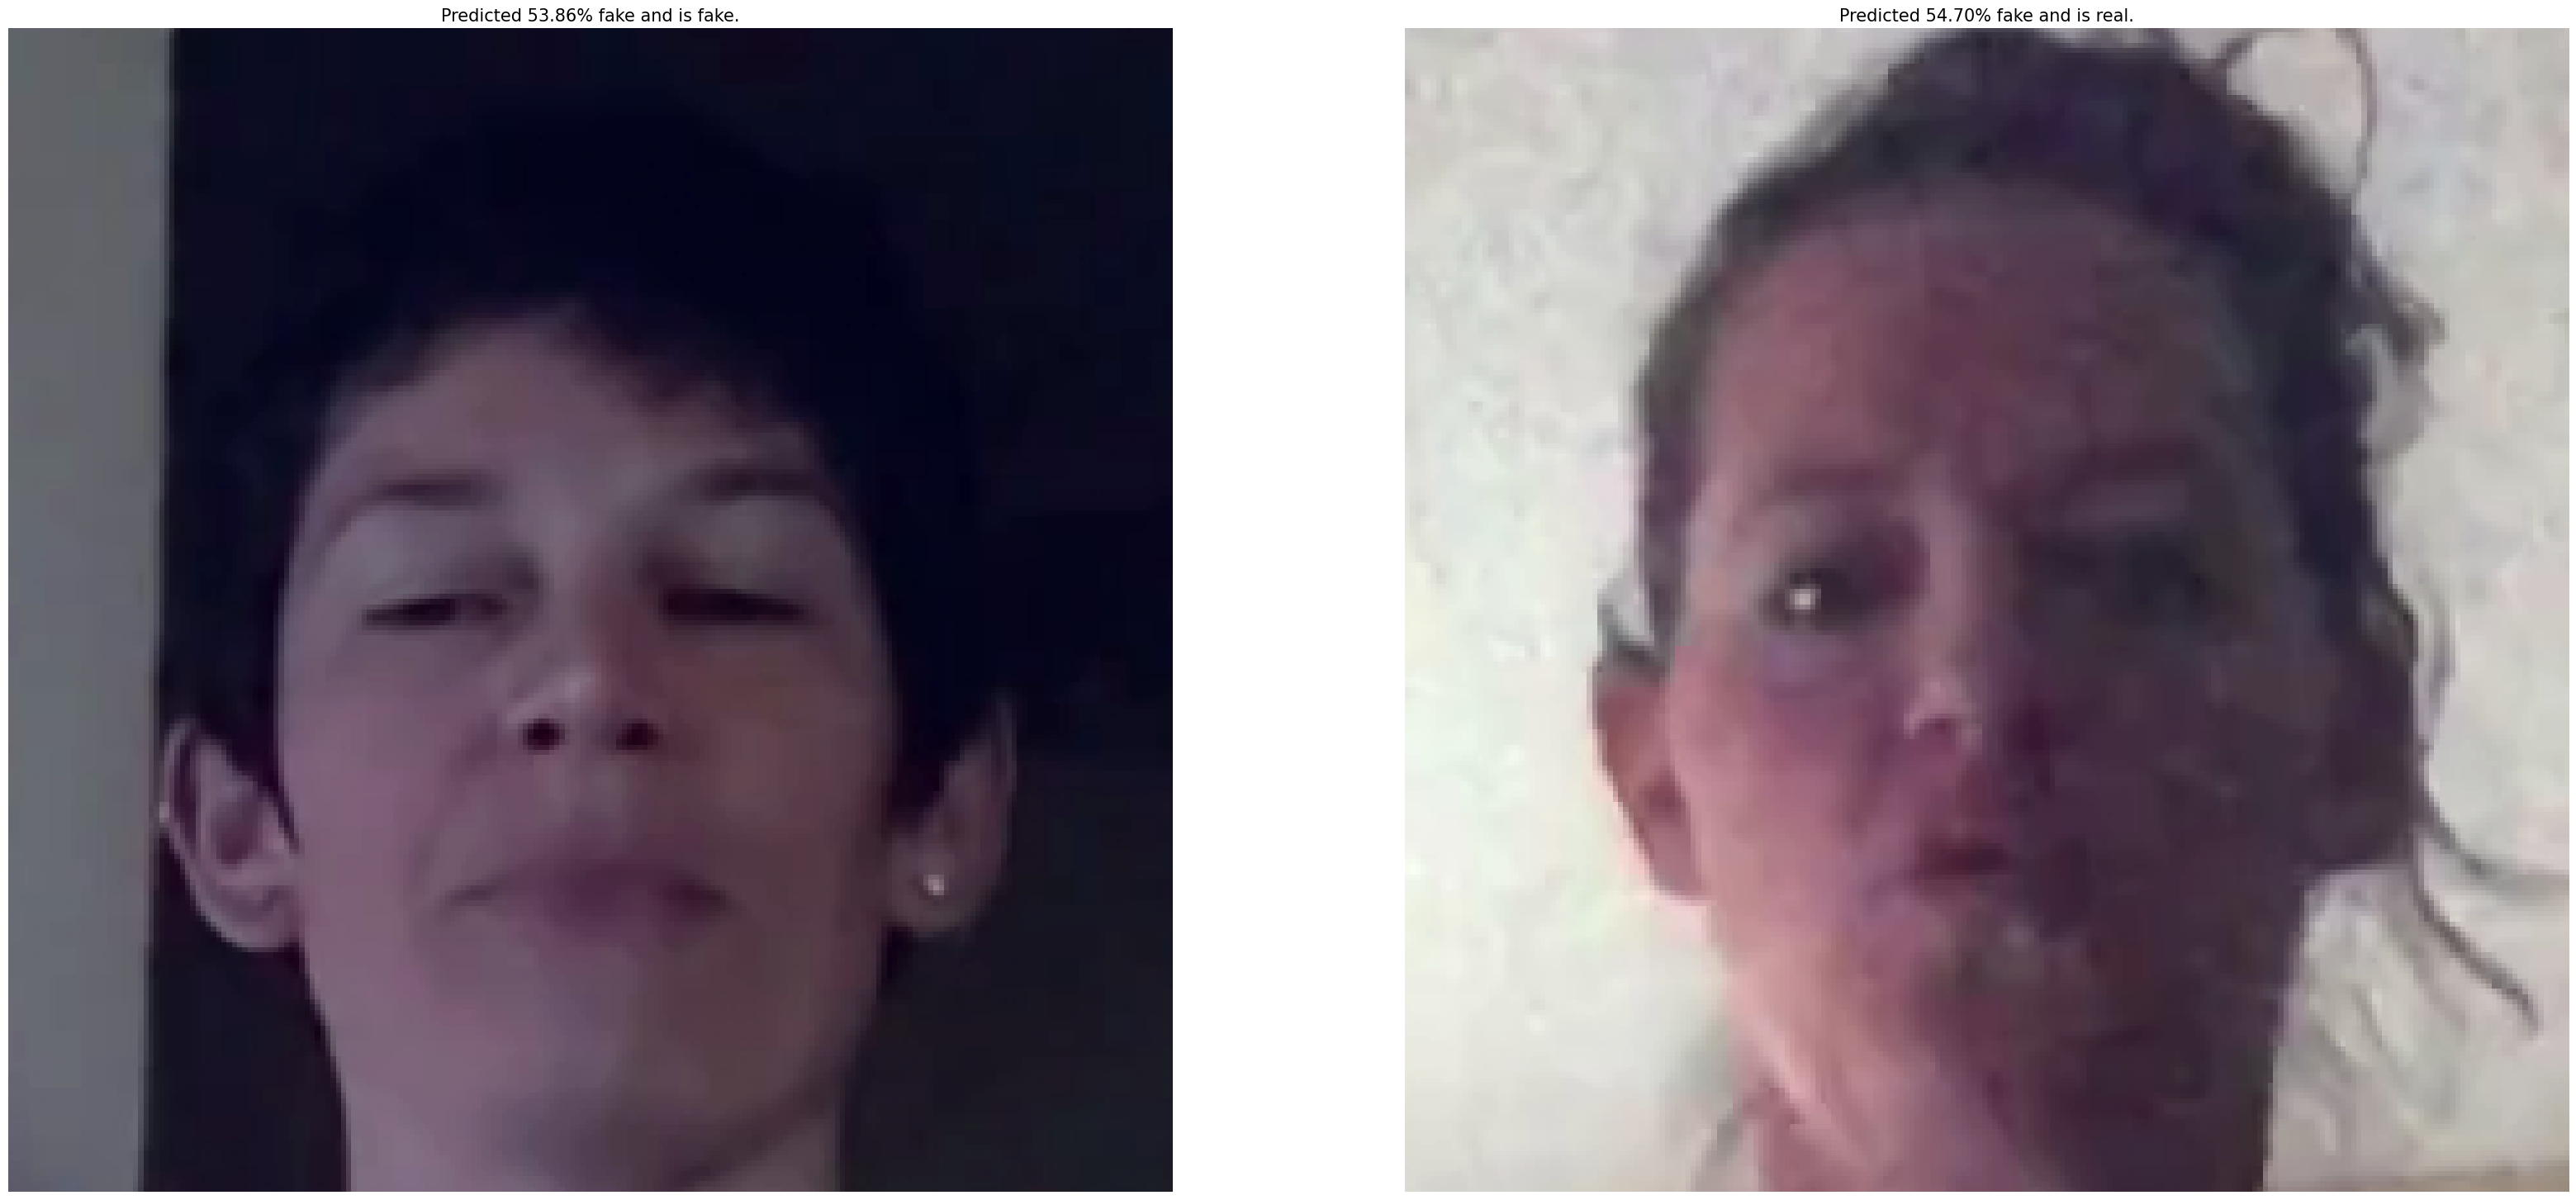

In [17]:
# Visualizing some videos from the test loader.
outs, images, labels = [], [], []
limit = 32
i = 1
for batch, y in test_loader:
    if i > limit:
        break
    outs.append(predict_video(model, batch))
    images.append(batch[0].cpu().numpy())
    labels.append(y[0])
    i += 1

images = scale_img(np.stack(images, axis = 0))
labels = np.stack(labels, axis = 0)
outs = np.stack(outs, axis = 0)
plot_predictions(images, outs, labels, fontsize = 15)

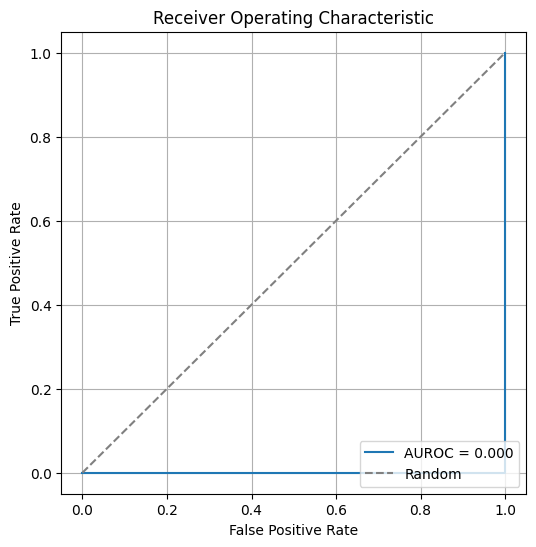

In [18]:
# Measuring the Area Under the Receiver Operating Characteristic Curve of the entire test set. 
auroc = AUROC(task = "binary")

preds, labels = [], []
for batch, y in test_loader:
    preds.append(predict_video(model, batch, return_float = False))
    labels.append(y[0])

preds = torch.stack(preds, axis = 0)
labels = torch.stack(labels, axis = 0).to(DEVICE)
roc_auc = auroc(preds, labels).item()

preds = preds.cpu().numpy()
labels = labels.cpu().numpy()

# Compute ROC curve
fpr, tpr, _ = roc_curve(labels, preds)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label = f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()